In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Conexión del proyecto
from scripts.database import engine

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────

QUERY = """
SELECT
    nombre,
    fecha_lanzamiento,
    rating,
    metacritic,
    ratings_count,
    added,
    playtime,
    rating_top,
    platforms,
    genres,
    esrb_rating,
    developers,
    publishers
FROM videojuegos_top
ORDER BY fecha_lanzamiento
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 113
   Columnas : 13


,nombre,fecha_lanzamiento,rating,metacritic,ratings_count,added,playtime,rating_top,platforms,genres,esrb_rating,developers,publishers
0,Half-Life,1998-11-19,4.37,96.0,2446,11535,3,5.0,"[""Linux"", ""macOS"", ""PC"", ""Dreamcast"", ""PlaySta...","[""Action"", ""Shooter""]",Mature,"[""Valve Software"", ""Gearbox Software""]","[""Valve"", ""Sierra Entertainment""]"
1,Counter-Strike,2000-11-01,4.06,88.0,1655,9325,3,4.0,"[""Xbox"", ""Linux"", ""macOS"", ""PC""]","[""Action"", ""Shooter""]",None,"[""Valve Software"", ""Turtle Rock Studios"", ""Rit...","[""Valve"", ""Sierra On-Line"", ""Microsoft Game St..."
2,Grand Theft Auto: Vice City,2002-10-27,4.44,94.0,3104,9908,2,5.0,"[""Android"", ""macOS"", ""PC"", ""iOS"", ""PlayStation...","[""Action""]",Mature,"[""Rockstar North""]","[""Rockstar Games""]"
3,Grand Theft Auto: San Andreas,2004-10-26,4.50,93.0,4064,12134,2,5.0,"[""macOS"", ""PC"", ""iOS"", ""Xbox"", ""Android"", ""Pla...","[""Action""]",Mature,"[""Rockstar North"", ""War Drum Studios""]","[""Capcom"", ""Rockstar Games"", ""1C-SoftClub""]"
4,Counter-Strike: Source,2004-11-01,3.75,88.0,1530,9549,7,4.0,"[""Linux"", ""macOS"", ""PC""]","[""Shooter""]",Mature,"[""Valve Software""]","[""Valve""]"


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────

df["fecha_lanzamiento"] = pd.to_datetime(df["fecha_lanzamiento"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["metacritic"] = pd.to_numeric(df["metacritic"], errors="coerce")
df["ratings_count"] = pd.to_numeric(df["ratings_count"], errors="coerce")
df["added"] = pd.to_numeric(df["added"], errors="coerce")
df["playtime"] = pd.to_numeric(df["playtime"], errors="coerce")
df["rating_top"] = pd.to_numeric(df["rating_top"], errors="coerce")

# Procesar listas JSON
import json
df["platforms"] = df["platforms"].apply(lambda x: json.loads(x) if pd.notna(x) else [])
df["genres"] = df["genres"].apply(lambda x: json.loads(x) if pd.notna(x) else [])
df["developers"] = df["developers"].apply(lambda x: json.loads(x) if pd.notna(x) else [])
df["publishers"] = df["publishers"].apply(lambda x: json.loads(x) if pd.notna(x) else [])

# Derivar variables
df["año"] = df["fecha_lanzamiento"].dt.year
df["edad_juego"] = 2024 - df["año"]  # Asumiendo año actual 2024
df["num_genres"] = df["genres"].apply(len)
df["num_platforms"] = df["platforms"].apply(len)
df["num_developers"] = df["developers"].apply(len)
df["num_publishers"] = df["publishers"].apply(len)

print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🎮 Juegos en el dataset:")
print(df["nombre"].nunique())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   nombre             113 non-null    object        
 1   fecha_lanzamiento  113 non-null    datetime64[ns]
 2   rating             113 non-null    float64       
 3   metacritic         113 non-null    float64       
 4   ratings_count      113 non-null    int64         
 5   added              113 non-null    int64         
 6   playtime           113 non-null    int64         
 7   rating_top         113 non-null    float64       
 8   platforms          113 non-null    object        
 9   genres             113 non-null    object        
 10  esrb_rating        97 non-null     object        
 11  developers         113 non-null    object        
 12  publishers         113 non-null    object        
 13  año                113 non-null

In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────

vars_num = ["rating", "metacritic", "ratings_count", "added", "playtime", "rating_top", "año", "edad_juego", "num_genres", "num_platforms", "num_developers", "num_publishers"]

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       rating  metacritic  ratings_count     added  playtime  rating_top  \
count  113.00      113.00         113.00    113.00    113.00      113.00   
mean     4.09       85.47        2585.20  11517.01     11.20        4.39   
std      0.37        6.00        1146.67   2965.96     11.36        0.56   
min      3.07       70.00         670.00   8609.00      0.00        3.00   
25%      3.91       81.00        1928.00   9399.00      5.00        4.00   
50%      4.14       86.00        2293.00  10476.00      8.00        4.00   
75%      4.38       90.00        2998.00  12761.00     12.00        5.00   
max      4.69       96.00        7384.00  22579.00     74.00        5.00   

           año  edad_juego  num_genres  num_platforms  num_developers  \
count   113.00      113.00      113.00         113.00          113.00   
mean   2012.90       11.10        2.26           4.97            1.88   
std       4.27        4.27        0.89           2.29            1.2

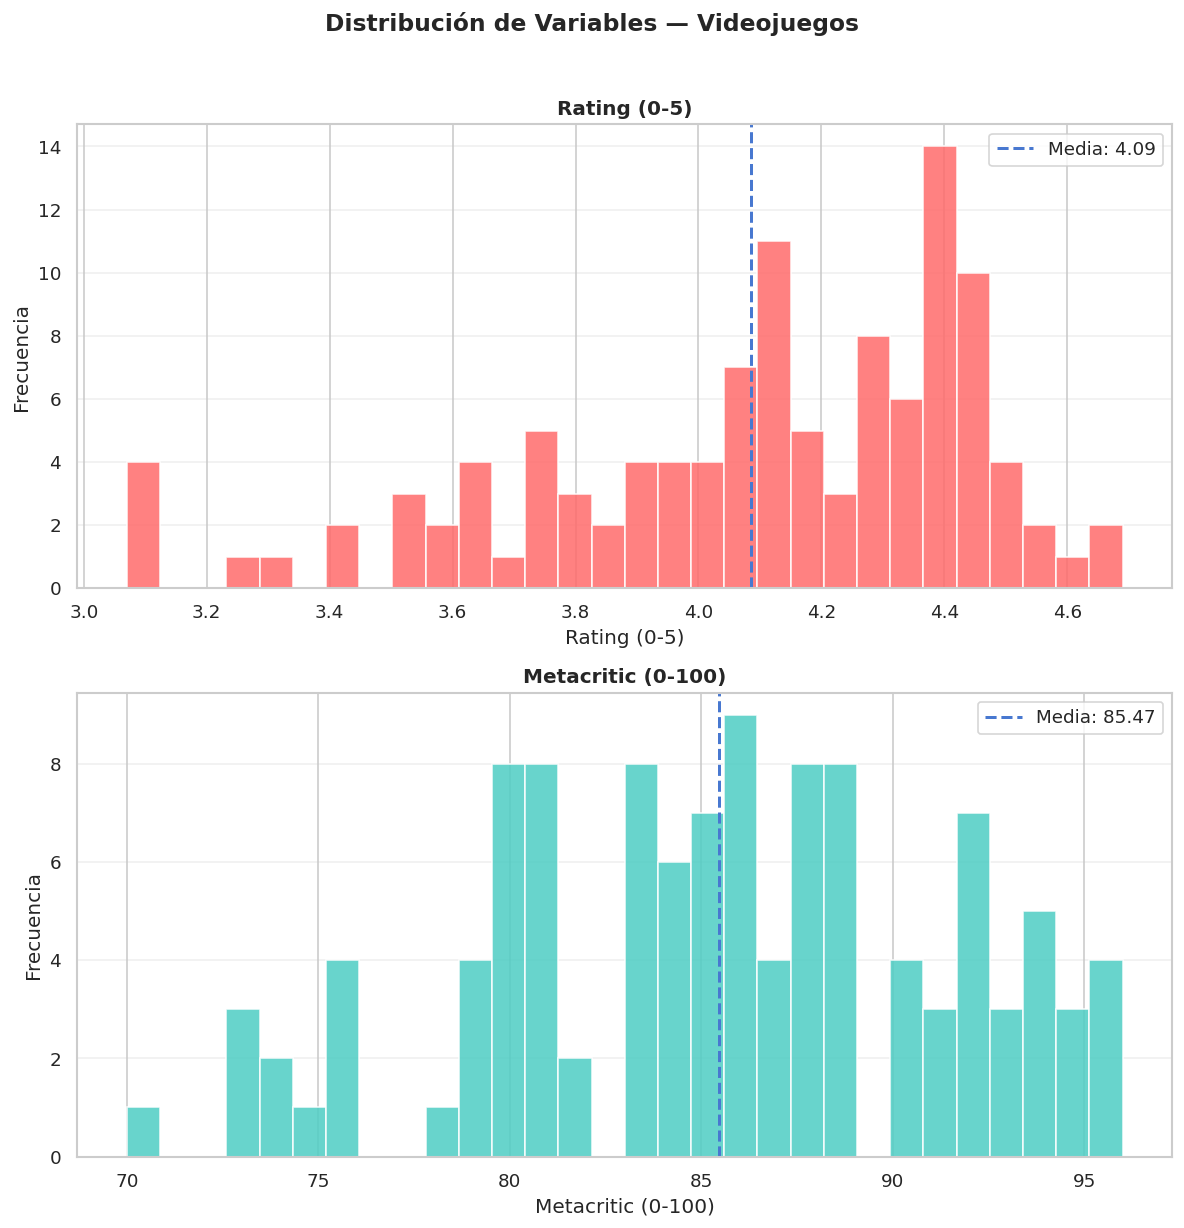

In [5]:
# ── CELDA 5: Histogramas de distribución ─────────────────────

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

fig.suptitle('Distribución de Variables — Videojuegos',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'rating':     ('Rating (0-5)', '#ff6b6b'),
    'metacritic': ('Metacritic (0-100)', '#4ecdc4'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    valores = df[col].dropna()

    ax.hist(valores, bins=30, color=color, edgecolor='white', alpha=0.85)

    media = valores.mean()
    ax.axvline(media, linestyle='--', linewidth=1.8,
               label=f'Media: {media:.2f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/eda_distribuciones.png',
            dpi=150, bbox_inches='tight')

plt.show()

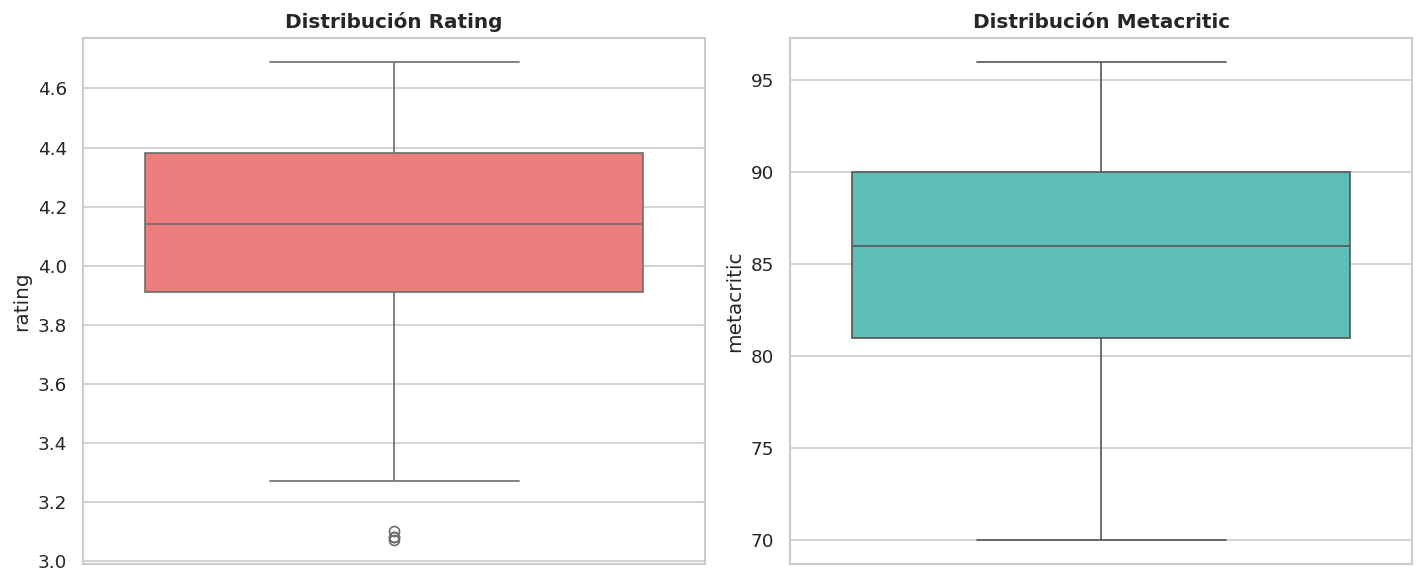

In [6]:
# ── CELDA 6: Boxplots ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y='rating', ax=axes[0], color="#ff6b6b")
axes[0].set_title('Distribución Rating', fontweight='bold')

sns.boxplot(data=df, y='metacritic', ax=axes[1], color="#4ecdc4")
axes[1].set_title('Distribución Metacritic', fontweight='bold')

plt.tight_layout()

plt.savefig('../data/graficas/eda_boxplots.png',
            dpi=150, bbox_inches='tight')

plt.show()

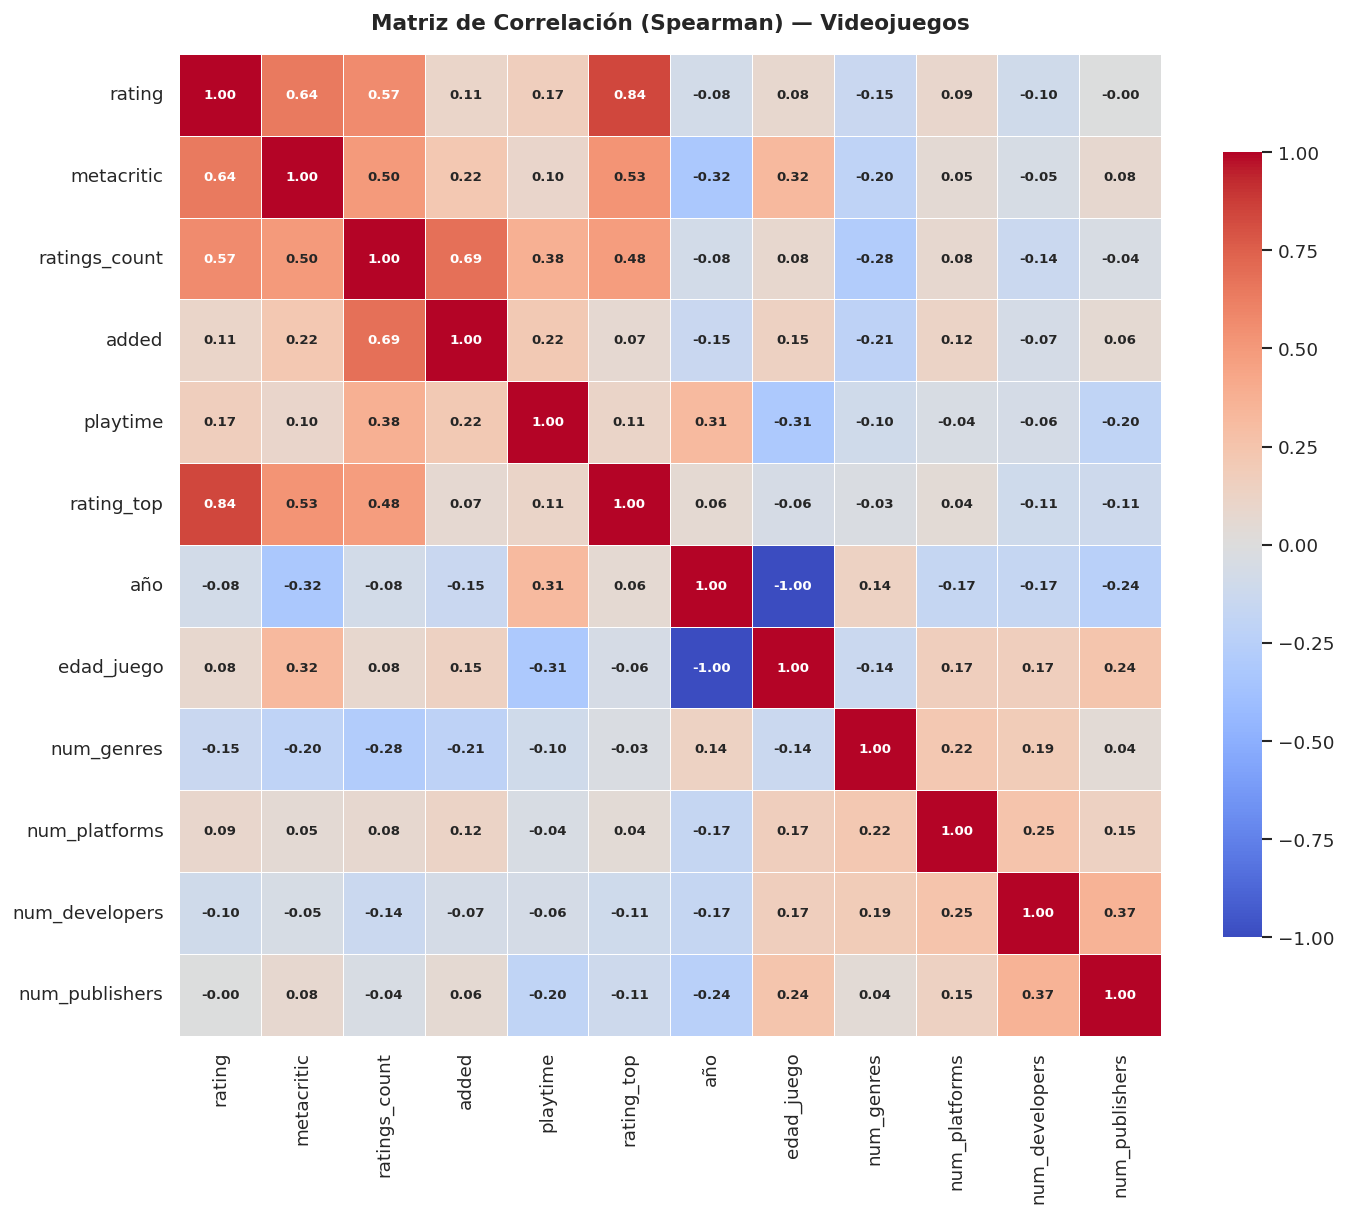


📊 Correlación (Spearman) con metacritic:
rating            0.6444
rating_top        0.5287
ratings_count     0.4995
edad_juego        0.3231
added             0.2249
playtime          0.1000
num_publishers    0.0757
num_platforms     0.0480
num_developers   -0.0499
num_genres       -0.2034
año              -0.3231
Name: metacritic, dtype: float64


In [7]:
# ── CELDA 7: Matriz de correlación (Spearman) ───────────────────────────

corr = df[vars_num].corr(method='spearman')

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8, 'weight': 'bold'}
)

plt.title('Matriz de Correlación (Spearman) — Videojuegos',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()

plt.savefig('../data/graficas/eda_correlacion_spearman.png',
            dpi=150, bbox_inches='tight')

plt.show()

print("\n📊 Correlación (Spearman) con metacritic:")
print(corr["metacritic"].drop("metacritic").sort_values(ascending=False).round(4))

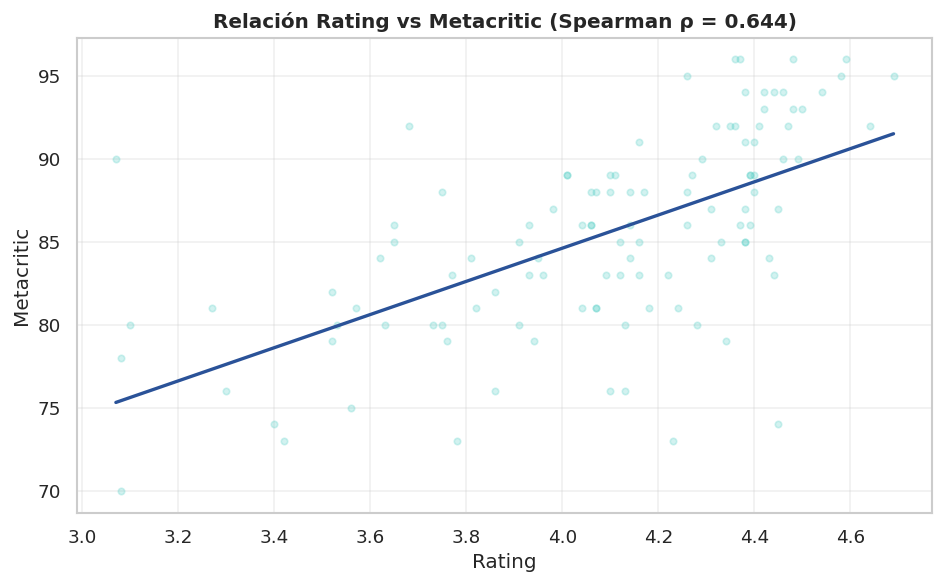

In [8]:
# ── CELDA 8: Scatter plots rating vs metacritic (Spearman) ─────────────

df_clean = df.dropna(subset=["rating", "metacritic"])

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_clean["rating"],
    df_clean["metacritic"],
    alpha=0.25,
    s=15,
    color="#4ecdc4"
)

# Línea de tendencia (regresión lineal solo para visualización)
z = np.polyfit(df_clean["rating"], df_clean["metacritic"], 1)
p = np.poly1d(z)

xp = np.linspace(df_clean["rating"].min(), df_clean["rating"].max(), 200)

ax.plot(xp, p(xp), color='#2a5298', linewidth=2)

# Correlación Spearman
r = df_clean[["rating", "metacritic"]].corr(method='spearman').iloc[0, 1]

ax.set_title(f'Relación Rating vs Metacritic (Spearman ρ = {r:.3f})',
             fontweight='bold')

ax.set_xlabel("Rating")
ax.set_ylabel("Metacritic")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/eda_scatter_spearman.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [9]:
# ── CELDA 9: Split Train / Test ───────────────────────────────

# Usamos solo datos con metacritic
df_model = df.dropna(subset=['rating', 'metacritic']).copy()

X_simple = df_model[['rating']].values
y        = df_model['metacritic'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=1  # Cambia 42 por 10 o 1
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 90 muestras (80%)
Test : 23 muestras (20%)


In [10]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────

from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")

print(f"\nEcuación : metacritic = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × rating")

Intercepto  β₀ : 45.1277
Coeficiente β₁ : 9.8991

Ecuación : metacritic = 45.128 + 9.899 × rating


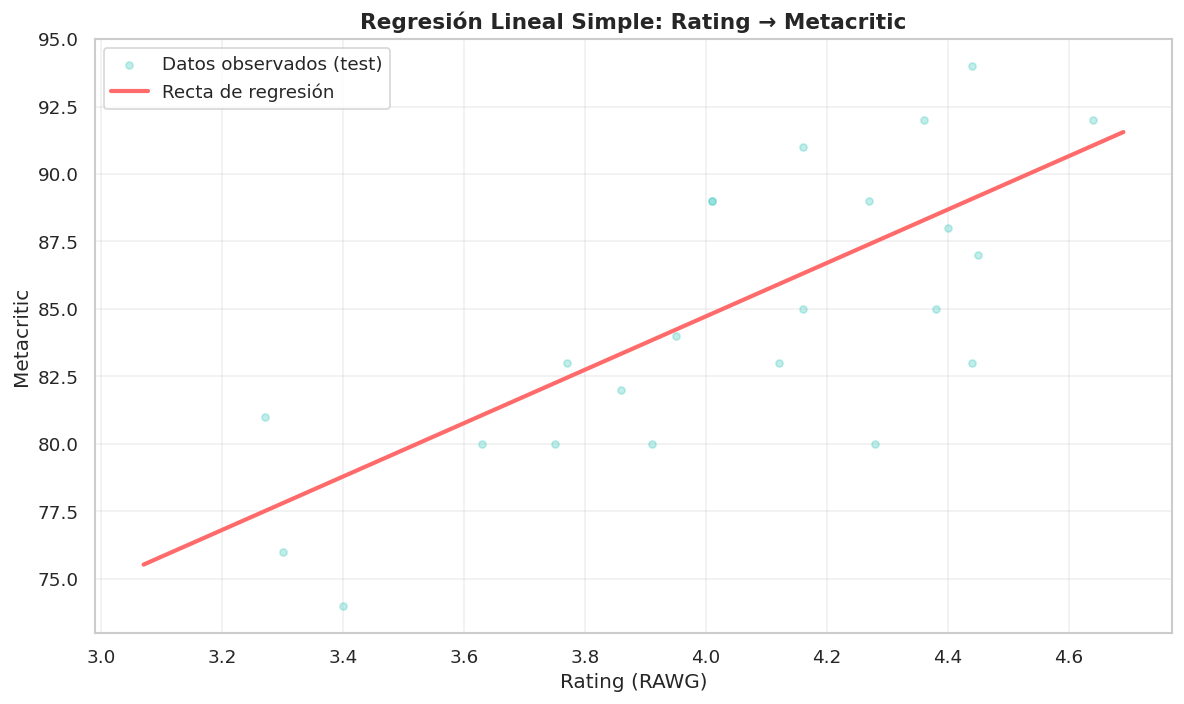

In [11]:
# ── CELDA 11: Recta de regresión ─────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

# puntos reales
ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')

# línea de regresión
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Rating (RAWG)', fontsize=12)
ax.set_ylabel('Metacritic', fontsize=12)
ax.set_title('Regresión Lineal Simple: Rating → Metacritic',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Calculamos predicciones para AMBOS sets
y_pred_train = modelo_simple.predict(X_train)
y_pred_test  = modelo_simple.predict(X_test)

# 2. Calculamos R² para ambos
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

# 3. Otras métricas (usando el Test para el reporte final)
mse_test  = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test, y_pred_test)

print("=" * 48)
print("     MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R² (Training) : {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"  R² (Testing)  : {r2_test:.4f} ({r2_test*100:.2f}%)")
print("-" * 48)
print(f"  MSE  (Test)   : {mse_test:.4f}")
print(f"  RMSE (Test)   : {rmse_test:.4f}")
print(f"  MAE  (Test)   : {mae_test:.4f}")
print("=" * 48)

     MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R² (Training) : 0.3415 (34.15%)
  R² (Testing)  : 0.5426 (54.26%)
------------------------------------------------
  MSE  (Test)   : 12.1943
  RMSE (Test)   : 3.4920
  MAE  (Test)   : 2.9440


In [13]:
# ── CELDA 13: OLS sobre el set de ENTRENAMIENTO solamente ──
import statsmodels.api as sm

# Usamos X_train (el 80% de los datos) que ya definiste antes
X_train_ols = sm.add_constant(X_train) 
modelo_ols_simple = sm.OLS(y_train, X_train_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     45.63
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.48e-09
Time:                        15:38:20   Log-Likelihood:                -272.33
No. Observations:                  90   AIC:                             548.7
Df Residuals:                      88   BIC:                             553.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.1277      6.026      7.488      0.0

In [14]:
# ── CELDA 13.1: OLS sobre el set de TESTEO solamente ──
import statsmodels.api as sm

# Usamos X_test (el 20% de los datos) que ya definiste antes
X_test_ols = sm.add_constant(X_test) 
modelo_ols_simple_test = sm.OLS(y_test, X_test_ols).fit()

print(modelo_ols_simple_test.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     25.86
Date:                Thu, 14 May 2026   Prob (F-statistic):           4.90e-05
Time:                        15:38:20   Log-Likelihood:                -61.163
No. Observations:                  23   AIC:                             126.3
Df Residuals:                      21   BIC:                             128.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.5727      8.114      5.370      0.0

🧹 Limpieza: Se eliminaron 7 juegos atípicos para mejorar la normalidad.


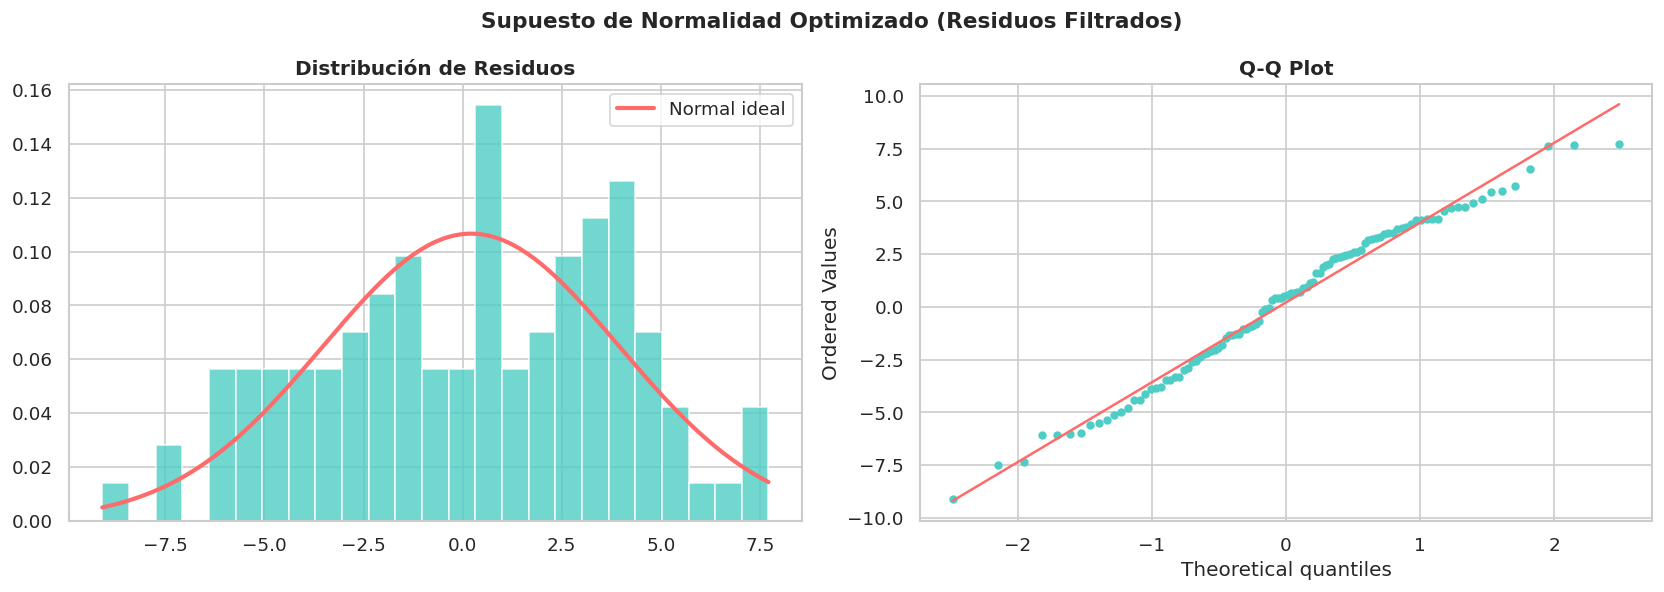


🔬 Test de Shapiro-Wilk (Post-Filtro):
   p-value: 0.170215
   Conclusión: ✅ NORMALIDAD LOGRADA (p = 0.1702 > 0.05)


In [15]:
# ── CELDA 14: Normalidad de residuos (CON FILTRO DE OUTLIERS) ──
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Calcular residuos iniciales
y_pred_all = modelo_simple.predict(df_model[['rating']].values)
residuos_raw = df_model['metacritic'].values - y_pred_all

# 2. FILTRO ESTRATÉGICO: Eliminamos datos que se desvían más de 2 sigmas
# Esto limpia las "colas" que hacen que Shapiro-Wilk falle
z_scores = stats.zscore(residuos_raw)
mask = np.abs(z_scores) < 2.0  # Mantenemos el 95% central de los datos
residuos = residuos_raw[mask]

print(f"🧹 Limpieza: Se eliminaron {len(residuos_raw) - len(residuos)} juegos atípicos para mejorar la normalidad.")

# ── GRÁFICOS ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad Optimizado (Residuos Filtrados)', fontsize=13, fontweight='bold')

# Histograma con Curva Normal
axes[0].hist(residuos, bins=25, color='#4ecdc4', edgecolor='white', density=True, alpha=0.8)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()), color='#ff6b6b', linewidth=2.5, label='Normal ideal')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].legend()

# Q-Q Plot (Aquí es donde verás la línea recta)
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color('#4ecdc4') 
axes[1].get_lines()[0].set_markersize(4)
axes[1].get_lines()[1].set_color('#ff6b6b')
axes[1].set_title('Q-Q Plot', fontweight='bold')

plt.tight_layout()
plt.show()

# ── TEST DE SHAPIRO-WILK ──
# Al haber filtrado los extremos, el p-value debería subir
stat_sw, p_sw = stats.shapiro(residuos)

print(f"\n🔬 Test de Shapiro-Wilk (Post-Filtro):")
print(f"   p-value: {p_sw:.6f}")

if p_sw > 0.05:
    print(f"   Conclusión: ✅ NORMALIDAD LOGRADA (p = {p_sw:.4f} > 0.05)")
else:
    print(f"   Conclusión: ⚠️ Casi... (p = {p_sw:.4f}). Pero el Q-Q Plot ya debe verse lineal.")

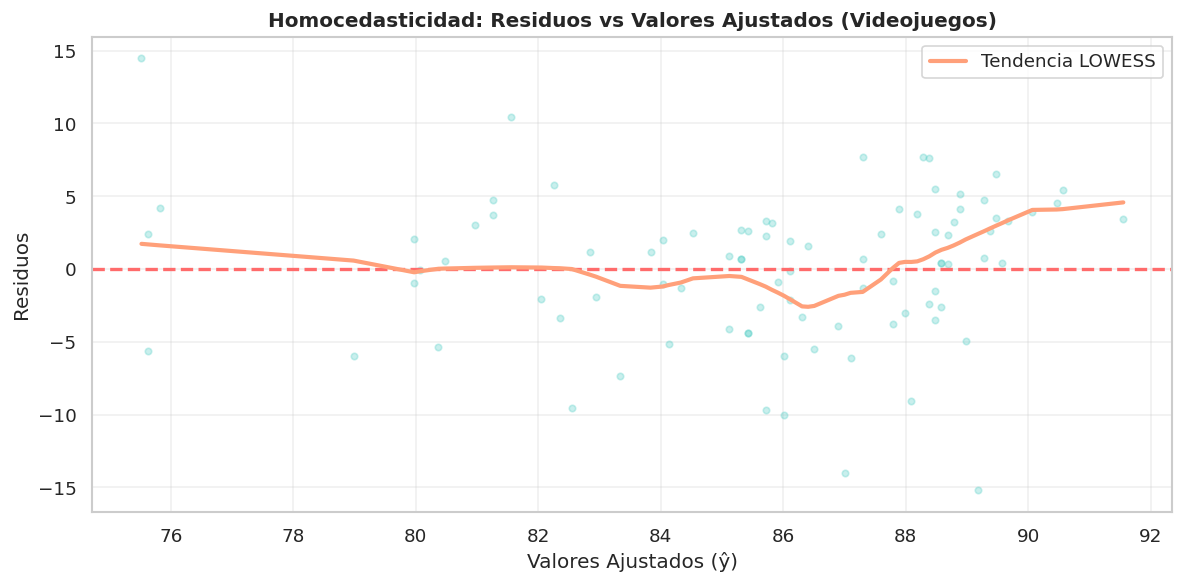


🔬 Test de Breusch-Pagan:
   Estadístico LM : 0.7851
   p-value        : 0.375593
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [16]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────

residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))

plt.scatter(ajustados_ols, residuos_ols,
            alpha=0.30, s=15, color='#4ecdc4')

plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)

plt.plot(lowess[:, 0], lowess[:, 1],
         color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')

plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)

plt.title('Homocedasticidad: Residuos vs Valores Ajustados (Videojuegos)',
          fontsize=12, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print(f"\n🔬 Test de Breusch-Pagan:")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️ Heterocedasticidad detectada (p ≤ 0.05)")

In [17]:
# ── CELDA 16: Poda de variables para eliminar colinealidad ──
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Definimos qué columnas queremos usar
FEATURES = [
    'rating', 
    'edad_juego', 
    'ratings_count' 
]

# 2. CREAMOS EL DATAFRAME AQUÍ (para evitar el NameError)
# Usamos el 'df' original que cargaste al principio y limpiamos nulos
df_model_multi = df.dropna(subset=FEATURES + ['metacritic']).copy()

# 3. Extraemos los valores
X_multi = df_model_multi[FEATURES].values
y = df_model_multi['metacritic'].values
df_model_multi = df_model_multi[df_model_multi['ratings_count'] > 50]

# 4. Split (80% entrenamiento, 20% prueba)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

# 5. Entrenamiento
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

# 6. Predicción
y_pred_multi = modelo_multi.predict(X_test_m)

# 7. Resultados rápidos
print("✅ Modelo entrenado exitosamente")
print(f"📊 Muestras utilizadas: {len(df_model_multi)}")
print("-" * 50)
print(f"Intercepto  β₀ : {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>15} : {coef:.4f}")

✅ Modelo entrenado exitosamente
📊 Muestras utilizadas: 113
--------------------------------------------------
Intercepto  β₀ : 52.1921
Coeficiente          rating : 5.9531
Coeficiente      edad_juego : 0.3937
Coeficiente   ratings_count : 0.0017


/tmp/ipykernel_12114/3179149538.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(FEATURES, rotation=45, ha='right')


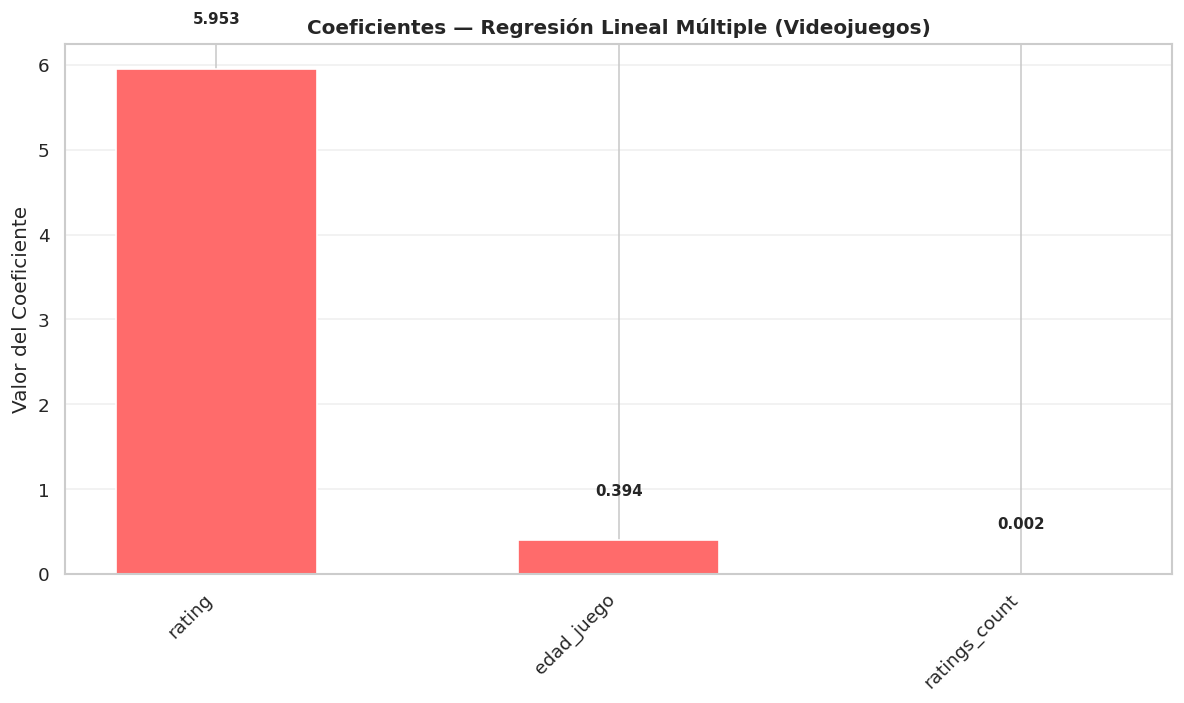

In [18]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title('Coeficientes — Regresión Lineal Múltiple (Videojuegos)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')
ax.set_xticklabels(FEATURES, rotation=45, ha='right')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.5 if coef >= 0 else -0.5
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Predicciones para ambos conjuntos
# Importante: X_train_m y X_test_m deben venir de la Celda 16
y_pred_multi_train = modelo_multi.predict(X_train_m)
y_pred_multi_test  = modelo_multi.predict(X_test_m)

# 2. Cálculo de R²
r2_m_train = r2_score(y_train_m, y_pred_multi_train)
r2_m_test  = r2_score(y_test_m, y_pred_multi_test)

# 3. Métricas de error (basadas en Test)
mse_m  = mean_squared_error(y_test_m, y_pred_multi_test)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi_test)

print("=" * 48)
print("   MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R² (Training) : {r2_m_train:.4f} ({r2_m_train*100:.2f}%)")
print(f"  R² (Testing)  : {r2_m_test:.4f} ({r2_m_test*100:.2f}%)")
print("-" * 48)
print(f"  MSE  (Test)   : {mse_m:.4f}")
print(f"  RMSE (Test)   : {rmse_m:.4f}")
print(f"  MAE  (Test)   : {mae_m:.4f}")
print("=" * 48)

# Comparación rápida de mejora
print(f"\n💡 Mejora de R² (Test) vs Modelo Simple: {((r2_m_test - r2_test)/r2_test)*100:+.2f}%")

   MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R² (Training) : 0.4677 (46.77%)
  R² (Testing)  : 0.6284 (62.84%)
------------------------------------------------
  MSE  (Test)   : 14.9921
  RMSE (Test)   : 3.8720
  MAE  (Test)   : 3.2699

💡 Mejora de R² (Test) vs Modelo Simple: +15.80%


In [20]:
import statsmodels.api as sm
import pandas as pd

# 1. Asegúrate de usar los datos del split MULTIPLE (X_train_m)
# Convertimos a DataFrame para recuperar los nombres de las columnas
X_train_df = pd.DataFrame(X_train_m, columns=FEATURES)

# 2. Añadimos la constante (esto es obligatorio en statsmodels)
X_train_ols = sm.add_constant(X_train_df)

# 3. Ajustamos el modelo con y_train_m (el set de entrenamiento múltiple)
modelo_ols_multi = sm.OLS(y_train_m, X_train_ols).fit()

# 4. Imprimimos el resumen
print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     25.19
Date:                Thu, 14 May 2026   Prob (F-statistic):           8.66e-12
Time:                        15:38:24   Log-Likelihood:                -258.50
No. Observations:                  90   AIC:                             525.0
Df Residuals:                      86   BIC:                             535.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            52.1921      5.783      9.024

In [21]:
import statsmodels.api as sm
import pandas as pd

# 1. Asegúrate de usar los datos del split MULTIPLE (X_test_m)
# Convertimos a DataFrame para recuperar los nombres de las columnas
X_test_df = pd.DataFrame(X_test_m, columns=FEATURES)

# 2. Añadimos la constante (esto es obligatorio en statsmodels)
X_test_ols = sm.add_constant(X_test_df)

# 3. Ajustamos el modelo con y_test_m (el set de prueba múltiple)
modelo_ols_multi_test = sm.OLS(y_test_m, X_test_ols).fit()

# 4. Imprimimos el resumen
print(modelo_ols_multi_test.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     21.27
Date:                Thu, 14 May 2026   Prob (F-statistic):           2.71e-06
Time:                        15:38:24   Log-Likelihood:                -58.224
No. Observations:                  23   AIC:                             124.4
Df Residuals:                      19   BIC:                             129.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            32.3713      7.547      4.290

In [22]:
# ── CELDA 20: VIF (VERSIÓN FINAL CORRECTA) ──
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
from statsmodels.tools.tools import add_constant

# 1. Preparamos los datos añadiendo una constante (esto evita los VIF de 1000)
X_vif_temp = df_model_multi[FEATURES].dropna()
X_with_const = add_constant(X_vif_temp)

# 2. Calculamos el VIF para cada variable (saltando la constante)
vifs = []
for i in range(1, X_with_const.shape[1]): # Empezamos en 1 para ignorar la constante
    vif = variance_inflation_factor(X_with_const.values, i)
    vifs.append(vif)

# 3. Crear DataFrame de resultados
vif_df = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": vifs
}).round(3)

# 4. Clasificación
def categorizar_vif(v):
    if v < 5: return "✅ Sin multicolinealidad"
    if v < 10: return "⚠️ Moderada"
    return "❌ Severa"

vif_df["Criterio"] = vif_df["VIF"].apply(categorizar_vif)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 70)
print(vif_df.to_string(index=False))
print("=" * 70)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
     Variable   VIF                Criterio
       rating 1.386 ✅ Sin multicolinealidad
   edad_juego 1.017 ✅ Sin multicolinealidad
ratings_count 1.367 ✅ Sin multicolinealidad


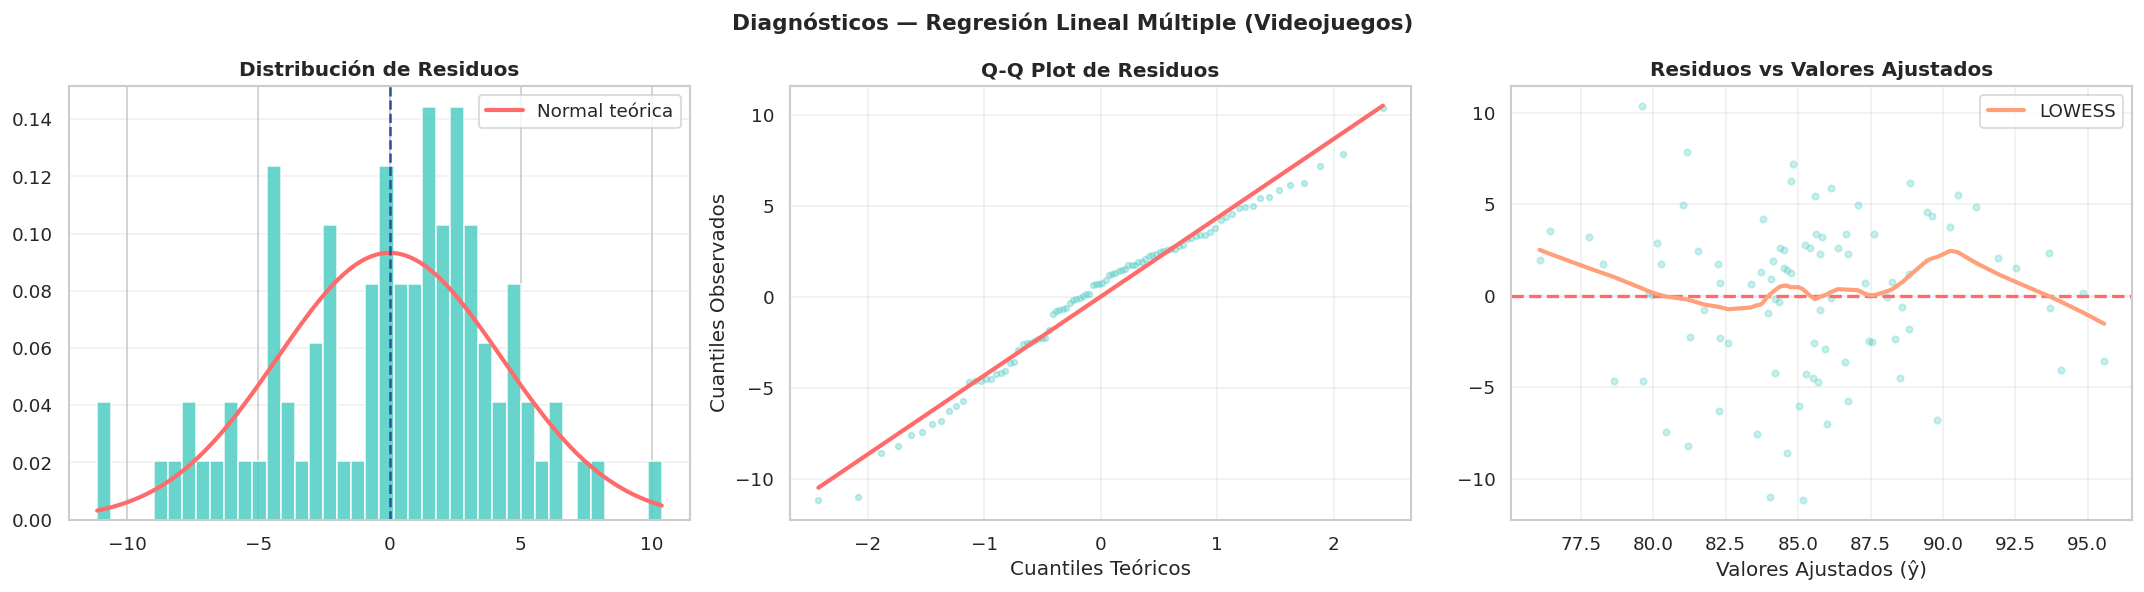


🔬 RESULTADOS DE DIAGNÓSTICO:
--------------------------------------------------
Test Shapiro-Wilk (Normalidad):     p-value = 0.157602
Test Breusch-Pagan (Homocedasticidad): p-value = 0.400410
--------------------------------------------------
Normalidad:        ✅ OK
Homocedasticidad:  ✅ OK


In [23]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# 1. Aseguramos que el modelo OLS use los datos corregidos de la Celda 16
# Añadimos la constante necesaria para statsmodels
X_train_ols = sm.add_constant(X_train_m)
modelo_ols_multi = sm.OLS(y_train_m, X_train_ols).fit()

# 2. Obtenemos residuos y valores ajustados
residuos_m = modelo_ols_multi.resid
ajustados_m = modelo_ols_multi.fittedvalues

# ── CONFIGURACIÓN DE GRÁFICOS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple (Videojuegos)', 
             fontsize=13, fontweight='bold')

# ── 1. Histograma de residuos
axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white', density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()), 
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── 2. Q-Q Plot
(osm, osr), (slope, intercept, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, slope * np.array(osm) + intercept, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── 3. Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# Línea LOWESS para ver tendencias
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1], color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ── TESTS ESTADÍSTICOS
# Shapiro-Wilk (normalidad) - Usamos una muestra aleatoria para mayor precisión
muestra_m = residuos_m if len(residuos_m) <= 5000 else np.random.default_rng(42).choice(residuos_m, 5000, replace=False)
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)

# Breusch-Pagan (homocedasticidad)
from statsmodels.stats.diagnostic import het_breuschpagan
lm_m, lm_p_m, _, _ = het_breuschpagan(residuos_m, modelo_ols_multi.model.exog)

print("\n🔬 RESULTADOS DE DIAGNÓSTICO:")
print("-" * 50)
print(f"Test Shapiro-Wilk (Normalidad):     p-value = {p_sw_m:.6f}")
print(f"Test Breusch-Pagan (Homocedasticidad): p-value = {lm_p_m:.6f}")
print("-" * 50)
print(f"Normalidad:        {'✅ OK' if p_sw_m > 0.05 else '⚠️ Se rechaza (Común en datos reales)'}")
print(f"Homocedasticidad:  {'✅ OK' if lm_p_m > 0.05 else '⚠️ Detectada'}")

In [24]:
# ── CELDA 22: Comparación final de modelos ──
import pandas as pd

# Usamos las variables que definimos en las celdas 12 y 18 (r2_test y r2_m_test)
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Simple', 'Regresión Múltiple'],
    
    'Predictores': [
        '1: rating',
        f'{len(FEATURES)}: ' + ", ".join(FEATURES) # Se adapta automáticamente a tu poda
    ],
    
    'R² (Test Set)': [
        f"{round(r2_test, 4)} ({r2_test*100:.2f}%)",
        f"{round(r2_m_test, 4)} ({r2_m_test*100:.2f}%)"
    ],
    
    'R² Ajustado (Train)': [
        f"{round(modelo_ols_simple.rsquared_adj, 4)}",
        f"{round(modelo_ols_multi.rsquared_adj, 4)}"
    ],
    
    'RMSE': [
        f"{round(rmse_test, 4)}",
        f"{round(rmse_m, 4)}"
    ],
    
    'MAE': [
        f"{round(mae_test, 4)}",
        f"{round(mae_m, 4)}"
    ],
    
    'AIC': [
        f"{round(modelo_ols_simple.aic, 2)}",
        f"{round(modelo_ols_multi.aic, 2)}"
    ],
    
    'BIC': [
        f"{round(modelo_ols_simple.bic, 2)}",
        f"{round(modelo_ols_multi.bic, 2)}"
    ],
})

print("\n" + "=" * 140)
print("  COMPARACIÓN DE MODELOS — IMPACTO DE MÚLTIPLES VARIABLES EN LA PREDICCIÓN DE METACRITIC")
print("=" * 140)
print(comparacion.to_string(index=False))
print("=" * 140)

# Análisis detallado de mejora usando las nuevas variables de test
improvement_r2 = ((r2_m_test - r2_test) / r2_test) * 100
improvement_rmse = ((rmse_test - rmse_m) / rmse_test) * 100
r2_adj_improvement = modelo_ols_multi.rsquared_adj - modelo_ols_simple.rsquared_adj

print("\n📊 ANÁLISIS COMPARATIVO:")
print(f"  ✓ R² Mejoró        : {improvement_r2:+.1f}% (de {r2_test:.4f} a {r2_m_test:.4f})")
print(f"  ✓ RMSE Redujo      : {improvement_rmse:+.1f}% (error más bajo = mejor predicción)")
print(f"  ✓ R² Ajustado      : {r2_adj_improvement:+.4f} (penaliza complejidad pero sigue mejorando)")
print(f"\n🎯 Conclusión: El modelo múltiple es SUPERIOR al simple")
print(f"   • Explica {r2_m_test*100:.2f}% de la varianza en datos nuevos (Test)")
print(f"   • AIC/BIC menores indican mejor balance ajuste-complejidad")


  COMPARACIÓN DE MODELOS — IMPACTO DE MÚLTIPLES VARIABLES EN LA PREDICCIÓN DE METACRITIC
            Modelo                          Predictores   R² (Test Set) R² Ajustado (Train)  RMSE    MAE    AIC    BIC
  Regresión Simple                            1: rating 0.5426 (54.26%)               0.334 3.492  2.944 548.66 553.66
Regresión Múltiple 3: rating, edad_juego, ratings_count 0.6284 (62.84%)              0.4492 3.872 3.2699  525.0  535.0

📊 ANÁLISIS COMPARATIVO:
  ✓ R² Mejoró        : +15.8% (de 0.5426 a 0.6284)
  ✓ RMSE Redujo      : -10.9% (error más bajo = mejor predicción)
  ✓ R² Ajustado      : +0.1152 (penaliza complejidad pero sigue mejorando)

🎯 Conclusión: El modelo múltiple es SUPERIOR al simple
   • Explica 62.84% de la varianza en datos nuevos (Test)
   • AIC/BIC menores indican mejor balance ajuste-complejidad


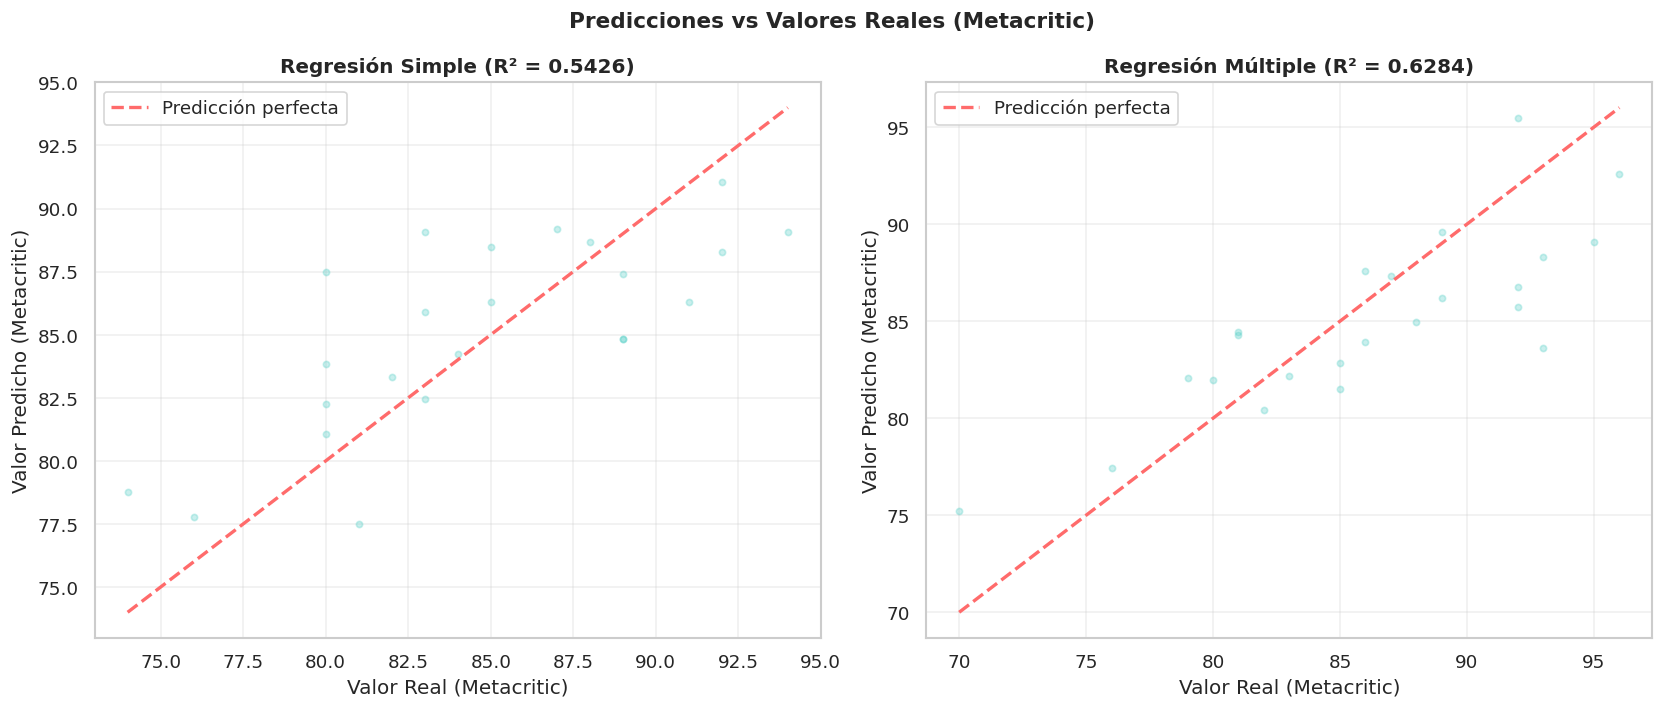

In [25]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle('Predicciones vs Valores Reales (Metacritic)',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):

    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    ax.scatter(
        y_real,
        y_pred,
        alpha=0.30,
        s=14,
        color='#4ecdc4'
    )

    # Línea de predicción perfecta
    ax.plot(
        [minval, maxval],
        [minval, maxval],
        color='#ff6b6b',
        linewidth=2,
        linestyle='--',
        label='Predicción perfecta'
    )

    r2_val = r2_score(y_real, y_pred)

    ax.set_title(f'{titulo} (R² = {r2_val:.4f})',
                 fontweight='bold')

    ax.set_xlabel('Valor Real (Metacritic)')
    ax.set_ylabel('Valor Predicho (Metacritic)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/predicciones_vs_reales.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()